 # MABe 2025: Advanced Lab-Specific Movement & Position Analysis



 **FOCUS: Per-Lab Differences with Emphasis on AdaptableSnail (Test Lab)**



 This notebook performs deep per-lab EDA focusing on:

 - Movement patterns and angular distributions by lab

 - Spatial occupancy heatmaps per lab

 - Body part positioning differences

 - Statistical comparisons between labs

 - **Special emphasis on AdaptableSnail vs other labs**

 ## 0. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Set visual style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams["figure.dpi"] = 120

# Create output directory
figures_dir = Path("eda/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Figures will be saved to: {figures_dir.absolute()}")

# File paths
base_path = Path("data/MABe-mouse-behavior-detection")
train_csv = base_path / "train.csv"
test_csv = base_path / "test.csv"


📁 Figures will be saved to: /home/mingjia-guan/workspaces/MABe-2025/eda/figures


 ## 1. Load Data and Lab Overview

In [2]:
# Load datasets
train = pd.read_csv(train_csv)
test = pd.read_csv(test_csv)

print("=" * 80)
print("DATASET DIMENSIONS")
print("=" * 80)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTest lab: {test['lab_id'].values[0]}")
print(f"Test video properties:")
print(f"  - FPS: {test['frames_per_second'].values[0]}")
print(f"  - Duration: {test['video_duration_sec'].values[0]} seconds")
print(f"  - Arena: {test['arena_width_cm'].values[0]}x{test['arena_height_cm'].values[0]} cm")


DATASET DIMENSIONS
Train shape: (8789, 38)
Test shape: (1, 38)

Test lab: AdaptableSnail
Test video properties:
  - FPS: 30.0
  - Duration: 614.7 seconds
  - Arena: 60.0x60.0 cm


 ## 2. Per-Lab Movement Statistics from Tracking Data

In [3]:
print("\n" + "=" * 80)
print("LOADING TRACKING DATA PER LAB")
print("=" * 80)

# Get lab-specific tracking files
lab_tracking_stats = {}

# Sample files from each lab (limit to avoid memory issues)
for lab_id in train['lab_id'].unique():
    lab_videos = train[train['lab_id'] == lab_id]

    # Get up to 3 sample videos per lab
    sample_videos = lab_videos.sample(n=min(3, len(lab_videos)), random_state=42)

    lab_movements = []
    lab_positions = []
    lab_speeds = []
    lab_angles = []

    for video_id in sample_videos['video_id']:
        # Find tracking file
        tracking_files = list((base_path / "train_tracking").rglob(f"*{video_id}*.parquet"))

        if len(tracking_files) > 0:
            try:
                df_track = pd.read_parquet(tracking_files[0])

                # Calculate movement metrics per mouse
                for mouse_id in df_track['mouse_id'].unique():
                    mouse_data = df_track[df_track['mouse_id'] == mouse_id].sort_values('video_frame')

                    if len(mouse_data) > 1:
                        # Position
                        lab_positions.extend(list(zip(mouse_data['x'], mouse_data['y'])))

                        # Frame-to-frame displacement
                        dx = mouse_data['x'].diff()
                        dy = mouse_data['y'].diff()
                        distance = np.sqrt(dx**2 + dy**2)

                        lab_movements.extend(distance.dropna().values)

                        # Speed (distance per frame)
                        lab_speeds.extend(distance.dropna().values)

                        # Movement angles
                        angles = np.arctan2(dy, dx) * 180 / np.pi
                        lab_angles.extend(angles.dropna().values)
            except Exception as e:
                print(f"  Error processing {video_id}: {e}")
                continue

    if len(lab_movements) > 0:
        lab_tracking_stats[lab_id] = {
            'movements': np.array(lab_movements),
            'positions': np.array(lab_positions),
            'speeds': np.array(lab_speeds),
            'angles': np.array(lab_angles),
            'n_samples': len(lab_movements)
        }
        print(f"✓ {lab_id}: {len(lab_movements):,} movement samples")
    else:
        print(f"✗ {lab_id}: No tracking data found")



LOADING TRACKING DATA PER LAB
✓ AdaptableSnail: 4,512,927 movement samples
✓ BoisterousParrot: 17,820,754 movement samples
✓ CRIM13: 301,988 movement samples
✓ CalMS21_supplemental: 725,782 movement samples
✓ CalMS21_task1: 519,086 movement samples
✓ CalMS21_task2: 933,402 movement samples
✓ CautiousGiraffe: 619,026 movement samples
✓ DeliriousFly: 2,592,138 movement samples
✓ ElegantMink: 1,440,869 movement samples
✓ GroovyShrew: 698,084 movement samples
✓ InvincibleJellyfish: 720,798 movement samples
✓ JovialSwallow: 361,335 movement samples
✓ LyricalHare: 1,091,144 movement samples
✓ MABe22_keypoints: 194,391 movement samples
✓ MABe22_movies: 194,391 movement samples
✓ NiftyGoldfinch: 790,494 movement samples
✓ PleasantMeerkat: 1,266,351 movement samples
✓ ReflectiveManatee: 634,082 movement samples
✓ SparklingTapir: 296,528 movement samples
✓ TranquilPanther: 1,381,877 movement samples
✓ UppityFerret: 1,259,910 movement samples


 ## 3. Movement Speed Distributions by Lab (Power Normalized)

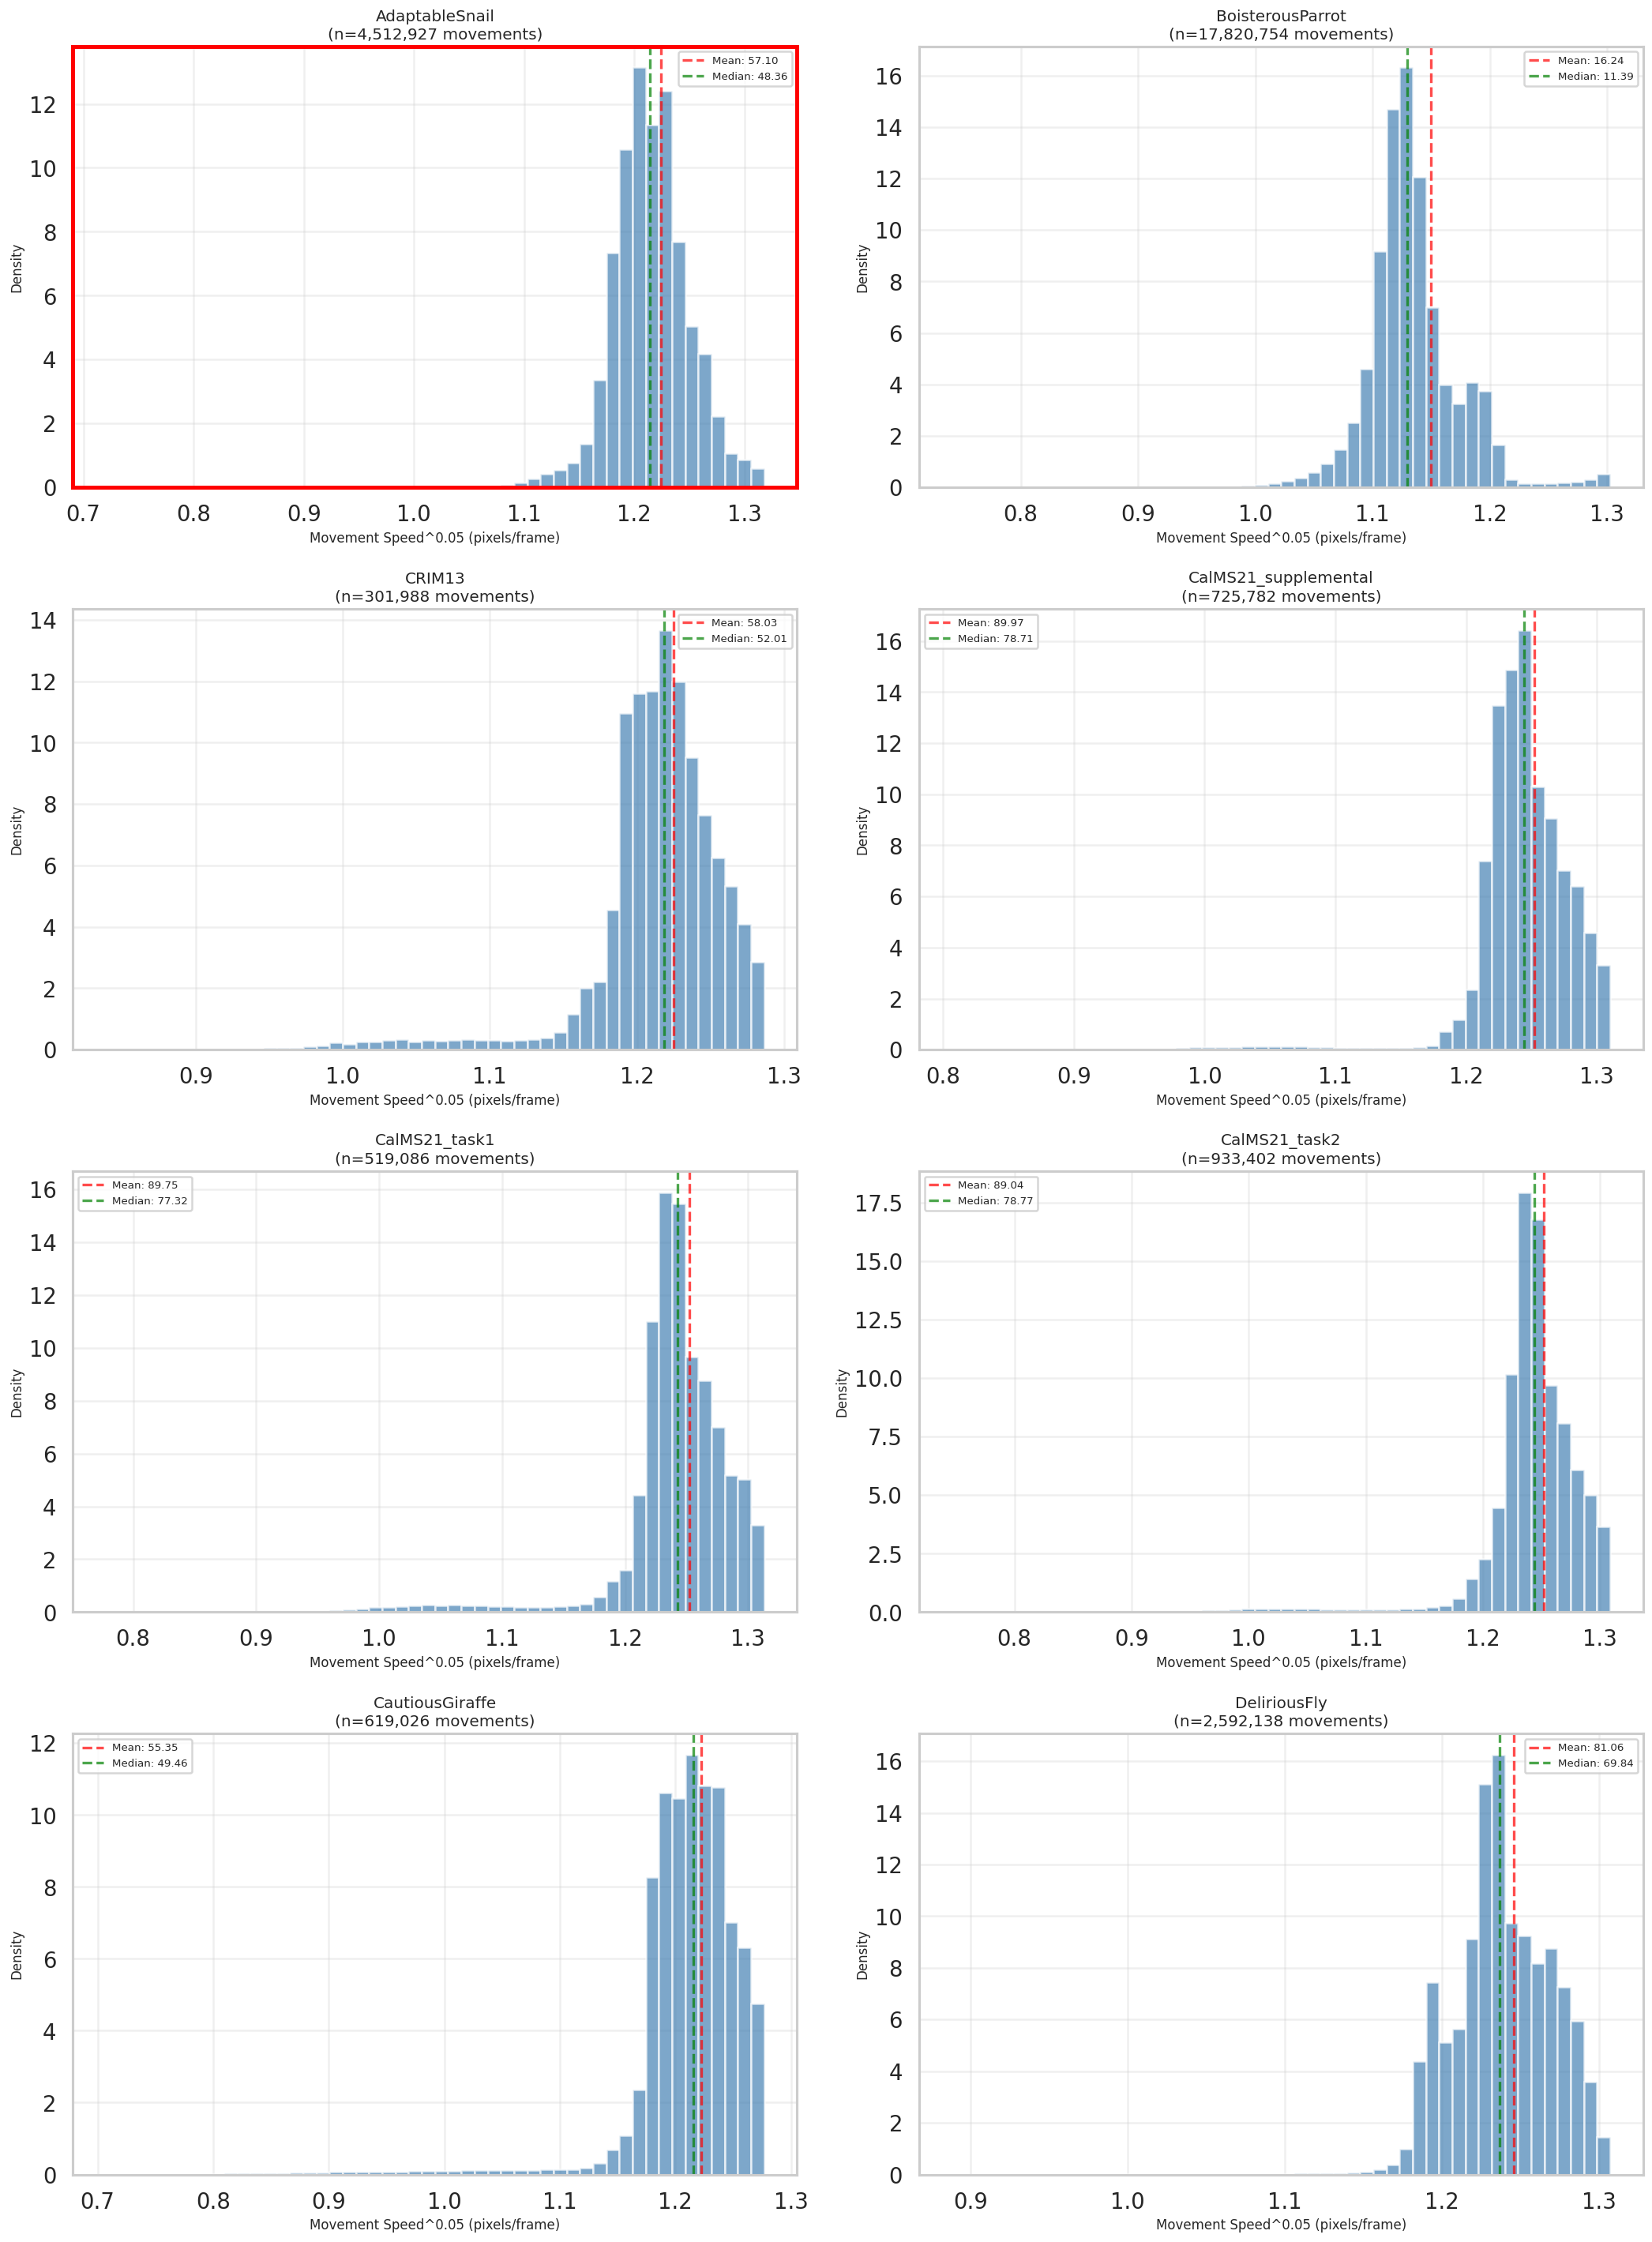

In [4]:
# Compare movement distributions across labs
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

# Power normalization (gamma = 0.05 for highly skewed data)
gamma = 0.05

for idx, (lab_id, stats_dict) in enumerate(sorted(lab_tracking_stats.items())):
    if idx >= 8:
        break

    ax = axes[idx]
    speeds = stats_dict['speeds']

    # Remove zeros and extreme outliers
    speeds_clean = speeds[(speeds > 0) & (speeds < np.percentile(speeds, 99))]

    # Apply power normalization
    speeds_norm = np.power(speeds_clean, gamma)

    # Plot with KDE
    ax.hist(speeds_norm, bins=50, alpha=0.7, color='steelblue', density=True)
    ax.set_title(f"{lab_id}\n(n={len(speeds):,} movements)", fontsize=12)
    ax.set_xlabel(f"Movement Speed^{gamma} (pixels/frame)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)

    # Add statistics
    mean_val = np.mean(speeds_clean)
    median_val = np.median(speeds_clean)
    ax.axvline(np.power(mean_val, gamma), color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label=f'Mean: {mean_val:.2f}')
    ax.axvline(np.power(median_val, gamma), color='green', linestyle='--', 
               linewidth=2, alpha=0.7, label=f'Median: {median_val:.2f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Highlight AdaptableSnail
    if lab_id == "AdaptableSnail":
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(figures_dir / "lab_movement_speed_distributions_power_norm.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


 ## 4. Angular Distribution Analysis by Lab

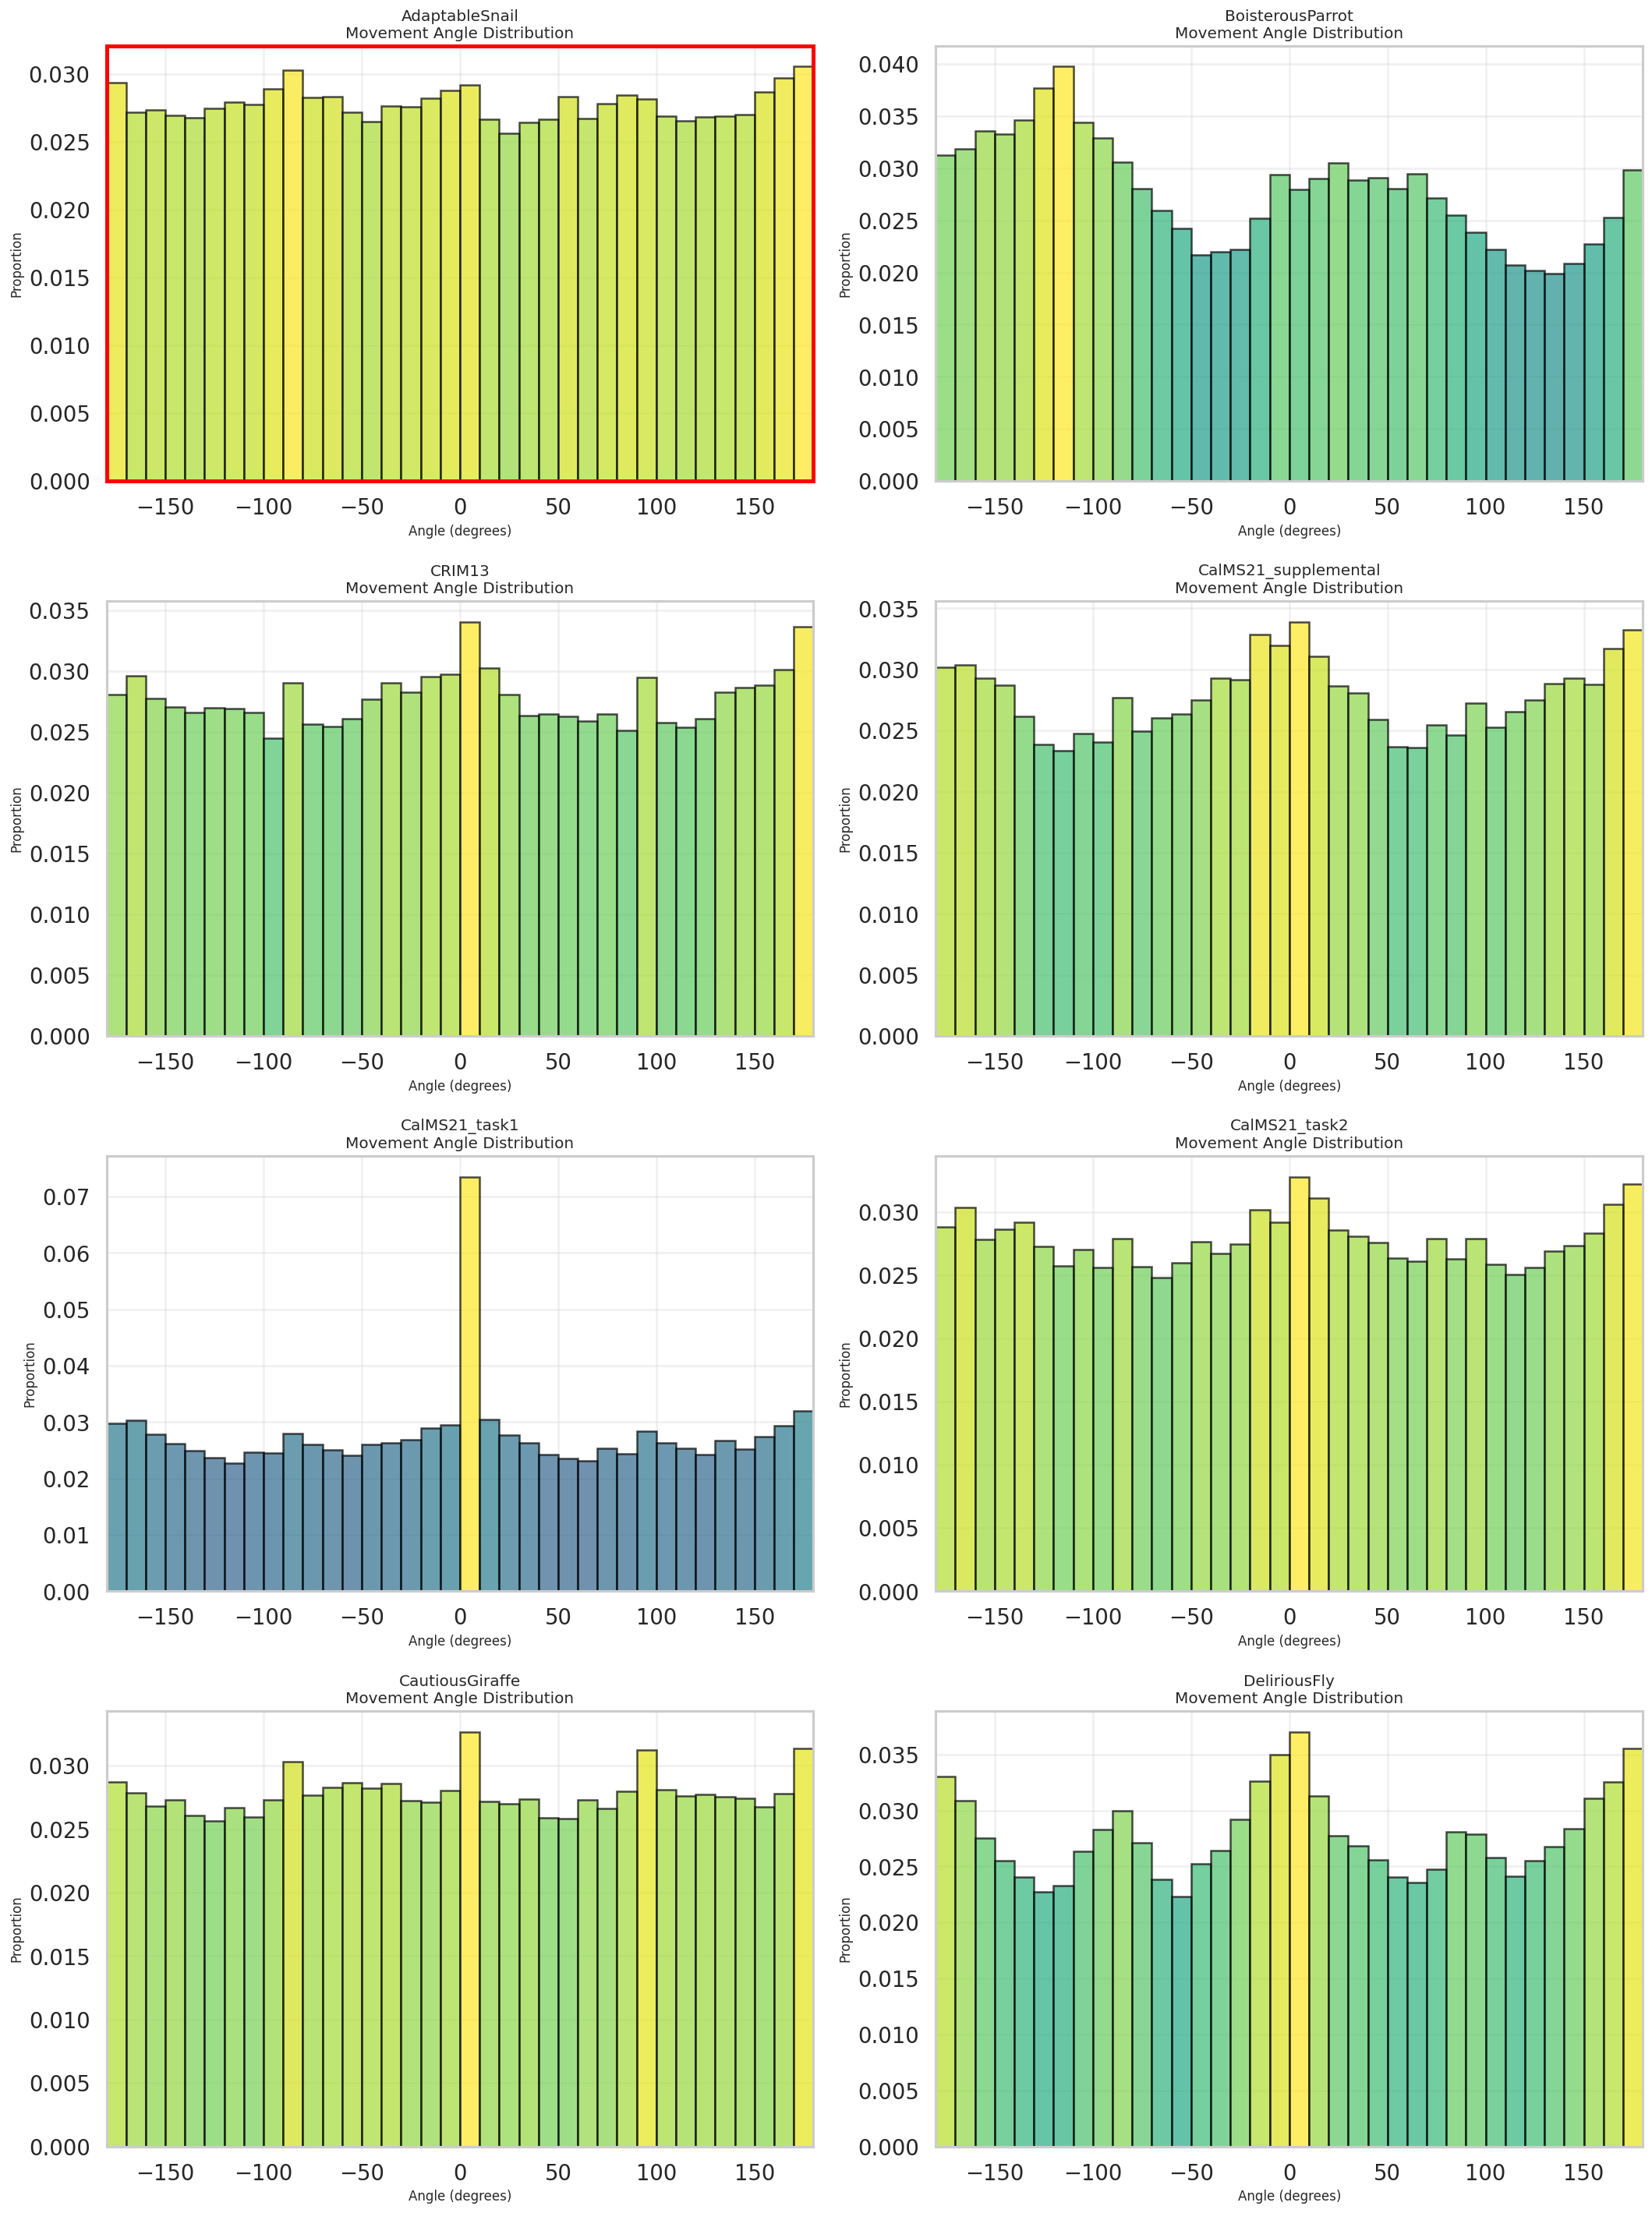

In [5]:
# Analyze movement angles (direction) by lab
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for idx, (lab_id, stats_dict) in enumerate(sorted(lab_tracking_stats.items())):
    if idx >= 8:
        break

    ax = axes[idx]
    angles = stats_dict['angles']

    # Circular histogram (rose plot style)
    bins = np.linspace(-180, 180, 37)
    hist, bin_edges = np.histogram(angles, bins=bins)

    # Normalize
    hist_norm = hist / hist.sum()

    # Bar plot
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    colors = plt.cm.viridis(hist_norm / hist_norm.max())

    ax.bar(bin_centers, hist_norm, width=10, color=colors, edgecolor='black', alpha=0.7)
    ax.set_title(f"{lab_id}\nMovement Angle Distribution", fontsize=12)
    ax.set_xlabel("Angle (degrees)", fontsize=10)
    ax.set_ylabel("Proportion", fontsize=10)
    ax.set_xlim(-180, 180)
    ax.grid(alpha=0.3)

    # Highlight AdaptableSnail
    if lab_id == "AdaptableSnail":
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(figures_dir / "lab_movement_angle_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


 ## 5. Spatial Occupancy Heatmaps by Lab (Power Normalized)

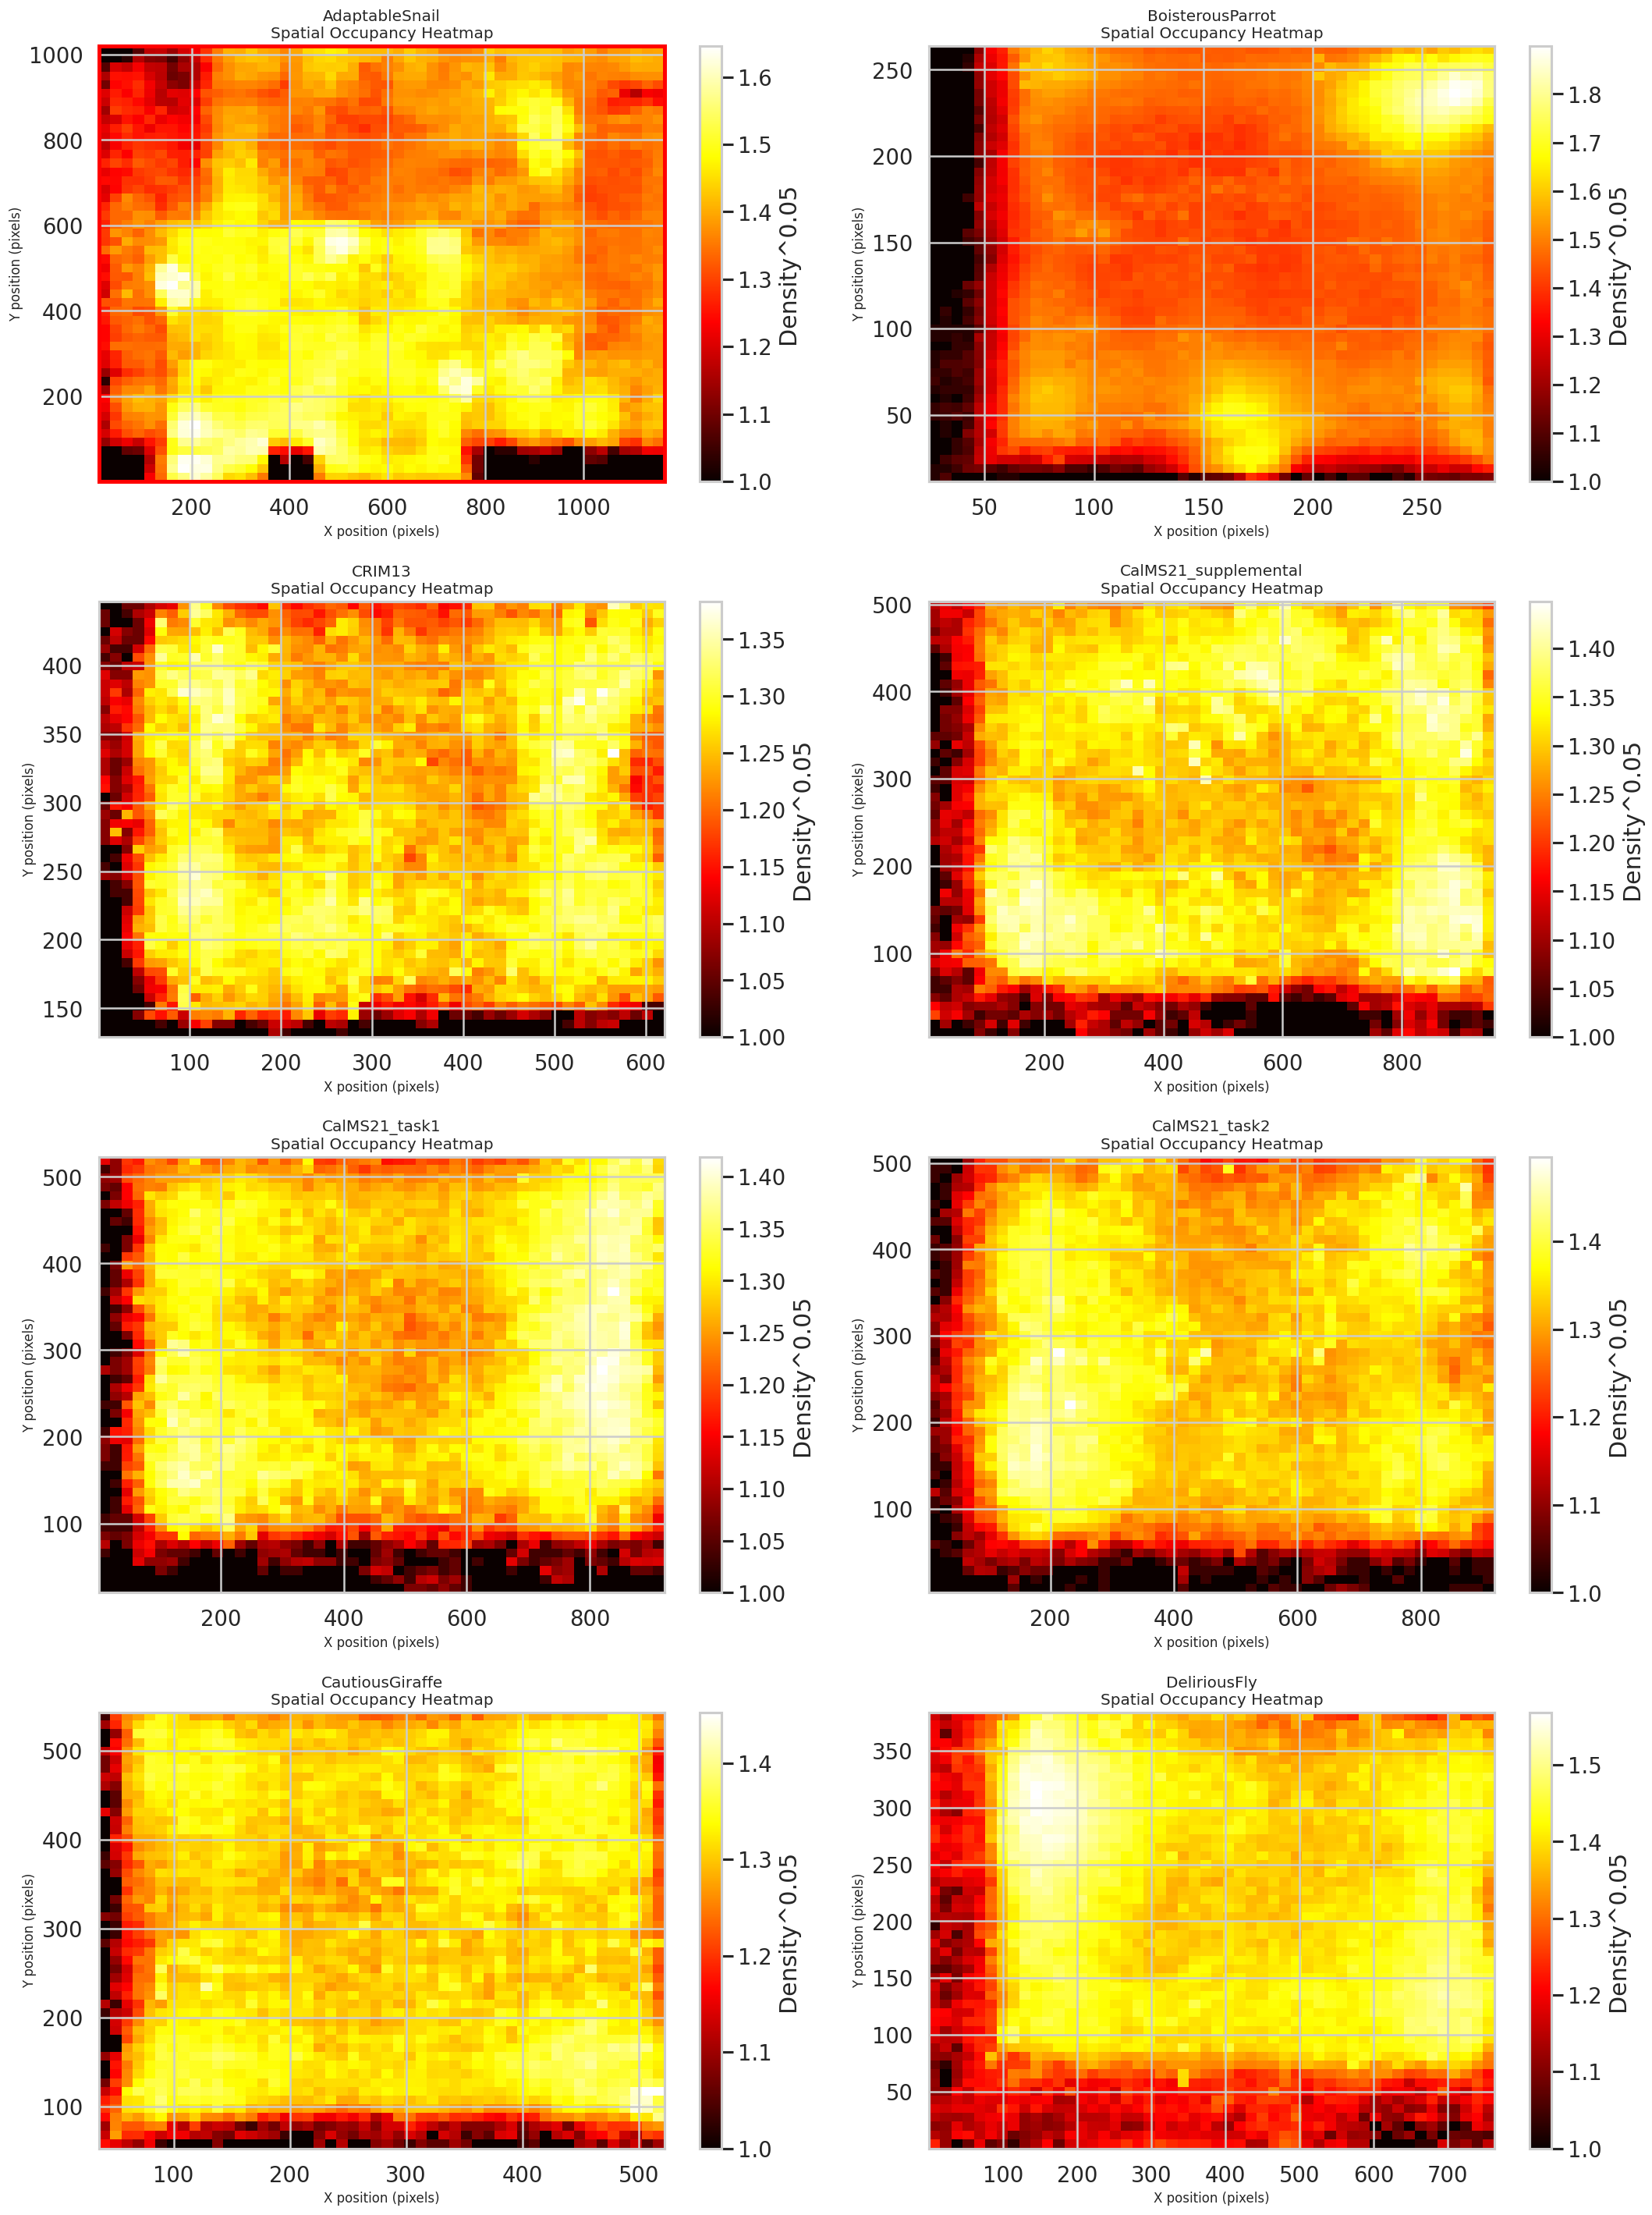

In [9]:
# %% [markdown]
# ## 5. Spatial Occupancy Heatmaps by Lab (Power Normalized) - FIXED

# %%
# Spatial heatmaps for each lab
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for idx, (lab_id, stats_dict) in enumerate(sorted(lab_tracking_stats.items())):
    if idx >= 8:
        break
    
    ax = axes[idx]
    positions = stats_dict['positions']
    
    if len(positions) > 0:
        x_coords = positions[:, 0]
        y_coords = positions[:, 1]
        
        # Remove extreme outliers while maintaining coordinate pairing
        # Create a combined mask for both x and y conditions
        x_valid = (x_coords > 0) & (x_coords < np.percentile(x_coords, 99))
        y_valid = (y_coords > 0) & (y_coords < np.percentile(y_coords, 99))
        
        # Apply combined mask to keep pairs together
        valid_mask = x_valid & y_valid
        x_clean = x_coords[valid_mask]
        y_clean = y_coords[valid_mask]
        
        # Verify same length
        assert len(x_clean) == len(y_clean), f"Dimension mismatch: {len(x_clean)} vs {len(y_clean)}"
        
        # 2D histogram
        H, xedges, yedges = np.histogram2d(x_clean, y_clean, bins=50)
        
        # Apply power normalization for visualization
        H_norm = np.power(H + 1, gamma)
        
        # Plot with PowerNorm colormap
        im = ax.imshow(H_norm.T, origin='lower', cmap='hot', aspect='auto',
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        
        ax.set_title(f"{lab_id}\nSpatial Occupancy Heatmap", fontsize=12)
        ax.set_xlabel("X position (pixels)", fontsize=10)
        ax.set_ylabel("Y position (pixels)", fontsize=10)
        plt.colorbar(im, ax=ax, label=f'Density^{gamma}')
        
        # Highlight AdaptableSnail
        if lab_id == "AdaptableSnail":
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(figures_dir / "lab_spatial_occupancy_heatmaps_power_norm.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


 ## 6. Statistical Comparison: AdaptableSnail vs Other Labs


STATISTICAL COMPARISON: ADAPTABLESNAIL VS OTHER LABS

Speed Differences (Mann-Whitney U Test):


,Lab,Speed_Median_Diff,Speed_P_Value,Significant_Speed
0,BoisterousParrot,37.262409,0.000000e+00,Yes
1,CRIM13,-3.628082,0.000000e+00,Yes
2,CalMS21_supplemental,-30.358986,0.000000e+00,Yes
3,CalMS21_task1,-27.388268,0.000000e+00,Yes
4,CalMS21_task2,-30.358986,0.000000e+00,Yes
6,DeliriousFly,-21.496330,0.000000e+00,Yes
7,ElegantMink,-16.072601,0.000000e+00,Yes
8,GroovyShrew,17.926514,0.000000e+00,Yes
12,MABe22_keypoints,15.611034,0.000000e+00,Yes
9,InvincibleJellyfish,-58.283073,0.000000e+00,Yes



Angle Differences (Kolmogorov-Smirnov Test):


,Lab,Angle_KS_Stat,Angle_P_Value,Significant_Angle
0,BoisterousParrot,0.060006,0.000000e+00,Yes
1,CRIM13,0.014199,5.360446e-50,Yes
2,CalMS21_supplemental,0.018647,2.854997e-189,Yes
3,CalMS21_task1,0.028862,0.000000e+00,Yes
4,CalMS21_task2,0.009778,1.162688e-64,Yes
6,DeliriousFly,0.021462,0.000000e+00,Yes
7,ElegantMink,0.029330,0.000000e+00,Yes
8,GroovyShrew,0.024670,4.650146e-320,Yes
12,MABe22_keypoints,0.020283,4.967540e-67,Yes
9,InvincibleJellyfish,0.014447,4.193077e-113,Yes


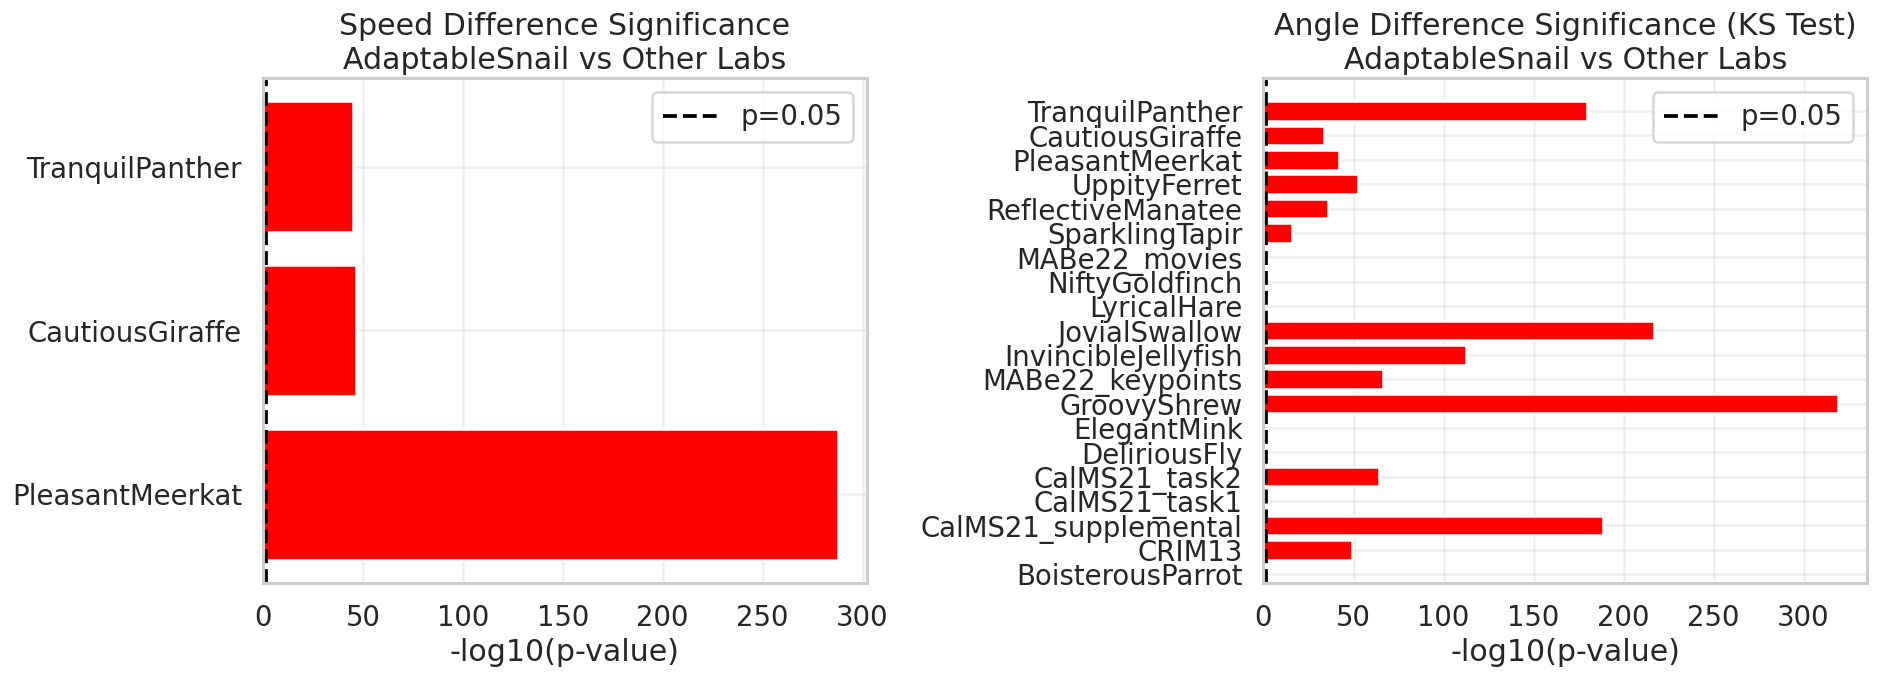

In [11]:
# %% [markdown]
# ## 6. Statistical Comparison: AdaptableSnail vs Other Labs - FIXED

# %%
print("\n" + "=" * 80)
print("STATISTICAL COMPARISON: ADAPTABLESNAIL VS OTHER LABS")
print("=" * 80)

if "AdaptableSnail" in lab_tracking_stats:
    adaptable_speeds = lab_tracking_stats["AdaptableSnail"]['speeds']
    adaptable_angles = lab_tracking_stats["AdaptableSnail"]['angles']
    
    comparison_results = []
    
    for lab_id, stats_dict in lab_tracking_stats.items():
        if lab_id != "AdaptableSnail":
            other_speeds = stats_dict['speeds']
            other_angles = stats_dict['angles']
            
            # Mann-Whitney U test for speeds (non-parametric)
            u_stat_speed, p_val_speed = stats.mannwhitneyu(
                adaptable_speeds, other_speeds, alternative='two-sided'
            )
            
            # For angle distributions, use Kolmogorov-Smirnov test instead of chi-square
            # KS test doesn't require equal sample sizes or totals
            ks_stat, p_val_angle = stats.ks_2samp(adaptable_angles, other_angles)
            
            # Alternative: Use chi-square with proper normalization
            bins = np.linspace(-180, 180, 37)
            adapt_hist, _ = np.histogram(adaptable_angles, bins=bins)
            other_hist, _ = np.histogram(other_angles, bins=bins)
            
            # Normalize to proportions (sum to 1)
            adapt_props = (adapt_hist + 1) / (adapt_hist.sum() + len(adapt_hist))
            other_props = (other_hist + 1) / (other_hist.sum() + len(other_hist))
            
            # Scale to same total for chi-square test
            total_samples = min(len(adaptable_angles), len(other_angles))
            adapt_scaled = adapt_props * total_samples
            other_scaled = other_props * total_samples
            
            # Now chi-square will work
            try:
                chi2_stat, p_val_chi2 = stats.chisquare(adapt_scaled, other_scaled)
            except ValueError:
                # If still fails, set to NaN
                chi2_stat, p_val_chi2 = np.nan, np.nan
            
            # Effect sizes
            median_diff_speed = np.median(adaptable_speeds) - np.median(other_speeds)
            mean_angle_diff = np.abs(np.mean(adaptable_angles) - np.mean(other_angles))
            
            comparison_results.append({
                'Lab': lab_id,
                'Speed_U_Stat': u_stat_speed,
                'Speed_P_Value': p_val_speed,
                'Speed_Median_Diff': median_diff_speed,
                'Angle_KS_Stat': ks_stat,
                'Angle_P_Value': p_val_angle,
                'Angle_Mean_Diff': mean_angle_diff,
                'Significant_Speed': 'Yes' if p_val_speed < 0.05 else 'No',
                'Significant_Angle': 'Yes' if p_val_angle < 0.05 else 'No'
            })
    
    comparison_df = pd.DataFrame(comparison_results)
    comparison_df = comparison_df.sort_values('Speed_P_Value')
    
    print("\nSpeed Differences (Mann-Whitney U Test):")
    display(comparison_df[['Lab', 'Speed_Median_Diff', 'Speed_P_Value', 'Significant_Speed']])
    
    print("\nAngle Differences (Kolmogorov-Smirnov Test):")
    display(comparison_df[['Lab', 'Angle_KS_Stat', 'Angle_P_Value', 'Significant_Angle']])
    
    # Visualize p-values
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax = axes[0]
    colors = ['red' if p < 0.05 else 'gray' for p in comparison_df['Speed_P_Value']]
    ax.barh(comparison_df['Lab'], -np.log10(comparison_df['Speed_P_Value']), color=colors)
    ax.axvline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Speed Difference Significance\nAdaptableSnail vs Other Labs')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1]
    colors = ['red' if p < 0.05 else 'gray' for p in comparison_df['Angle_P_Value']]
    ax.barh(comparison_df['Lab'], -np.log10(comparison_df['Angle_P_Value']), color=colors)
    ax.axvline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Angle Difference Significance (KS Test)\nAdaptableSnail vs Other Labs')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(figures_dir / "adaptablesnail_comparison_pvalues.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
else:
    print("⚠️  AdaptableSnail data not found in tracking stats")


 ## 7. Body Part Position Analysis by Lab


BODY PART POSITION ANALYSIS BY LAB
✓ AdaptableSnail: 18 body parts analyzed
✓ BoisterousParrot: 5 body parts analyzed
✓ CRIM13: 7 body parts analyzed
✓ CalMS21_supplemental: 7 body parts analyzed
✓ CalMS21_task1: 7 body parts analyzed


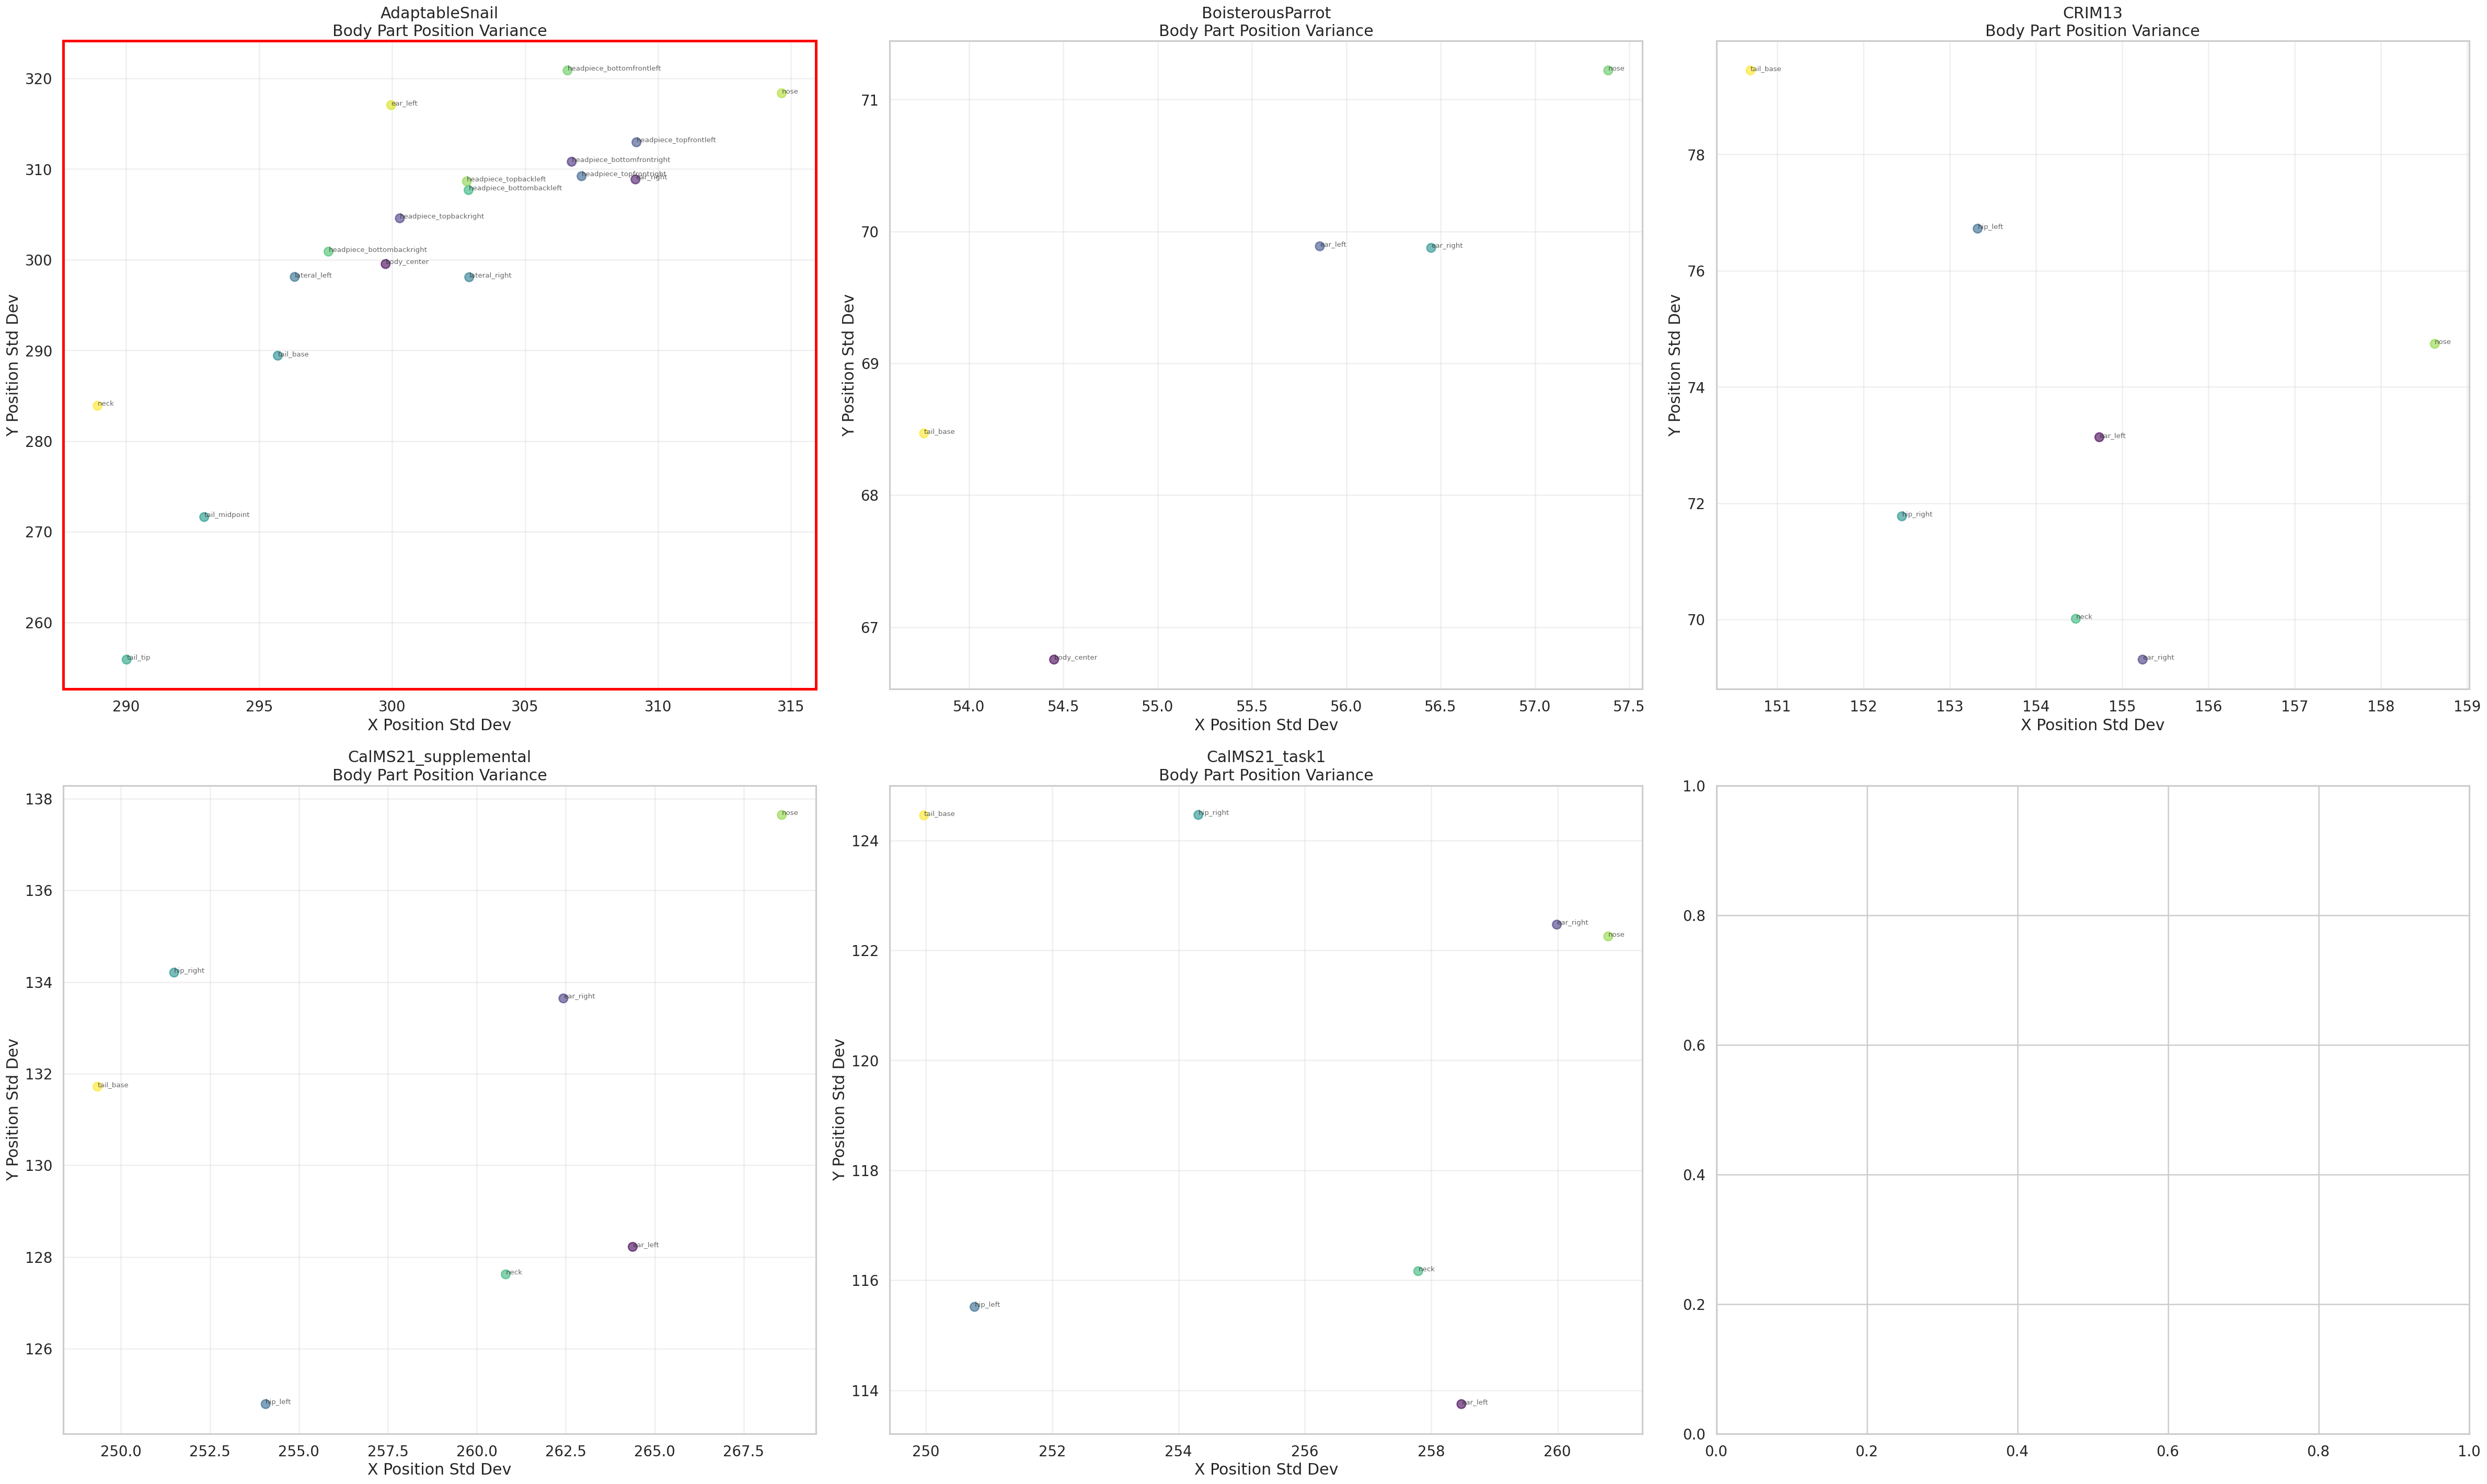

In [17]:
print("\n" + "=" * 80)
print("BODY PART POSITION ANALYSIS BY LAB")
print("=" * 80)

# Analyze body part distributions
bodypart_by_lab = {}

for lab_id in sorted(lab_tracking_stats.keys())[:5]:  # Top 5 labs
    lab_videos = train[train['lab_id'] == lab_id]
    sample_video = lab_videos.sample(n=1, random_state=42)

    for video_id in sample_video['video_id']:
        tracking_files = list((base_path / "train_tracking").rglob(f"*{video_id}*.parquet"))

        if len(tracking_files) > 0:
            try:
                df_track = pd.read_parquet(tracking_files[0])

                bodypart_positions = {}
                for bodypart in df_track['bodypart'].unique():
                    bp_data = df_track[df_track['bodypart'] == bodypart]
                    bodypart_positions[bodypart] = {
                        'x_mean': bp_data['x'].mean(),
                        'y_mean': bp_data['y'].mean(),
                        'x_std': bp_data['x'].std(),
                        'y_std': bp_data['y'].std()
                    }

                bodypart_by_lab[lab_id] = bodypart_positions
                print(f"✓ {lab_id}: {len(bodypart_positions)} body parts analyzed")
            except Exception as e:
                print(f"✗ {lab_id}: Error - {e}")

# Visualize body part variance
if len(bodypart_by_lab) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(40, 24))
    axes = axes.flatten()

    for idx, (lab_id, bp_dict) in enumerate(list(bodypart_by_lab.items())[:6]):
        ax = axes[idx]

        bodyparts = list(bp_dict.keys())
        x_stds = [bp_dict[bp]['x_std'] for bp in bodyparts]
        y_stds = [bp_dict[bp]['y_std'] for bp in bodyparts]

        # Scatter plot of variance
        ax.scatter(x_stds, y_stds, s=100, alpha=0.6, c=range(len(bodyparts)), cmap='viridis')

        for i, bp in enumerate(bodyparts):
            ax.annotate(bp, (x_stds[i], y_stds[i]), fontsize=8, alpha=0.7)

        ax.set_xlabel('X Position Std Dev')
        ax.set_ylabel('Y Position Std Dev')
        ax.set_title(f'{lab_id}\nBody Part Position Variance')
        ax.grid(alpha=0.3)

        # Highlight AdaptableSnail
        if lab_id == "AdaptableSnail":
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)

    plt.tight_layout()
    plt.savefig(figures_dir / "bodypart_position_variance_by_lab.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


 ## 8. Movement Speed vs Video Properties by Lab

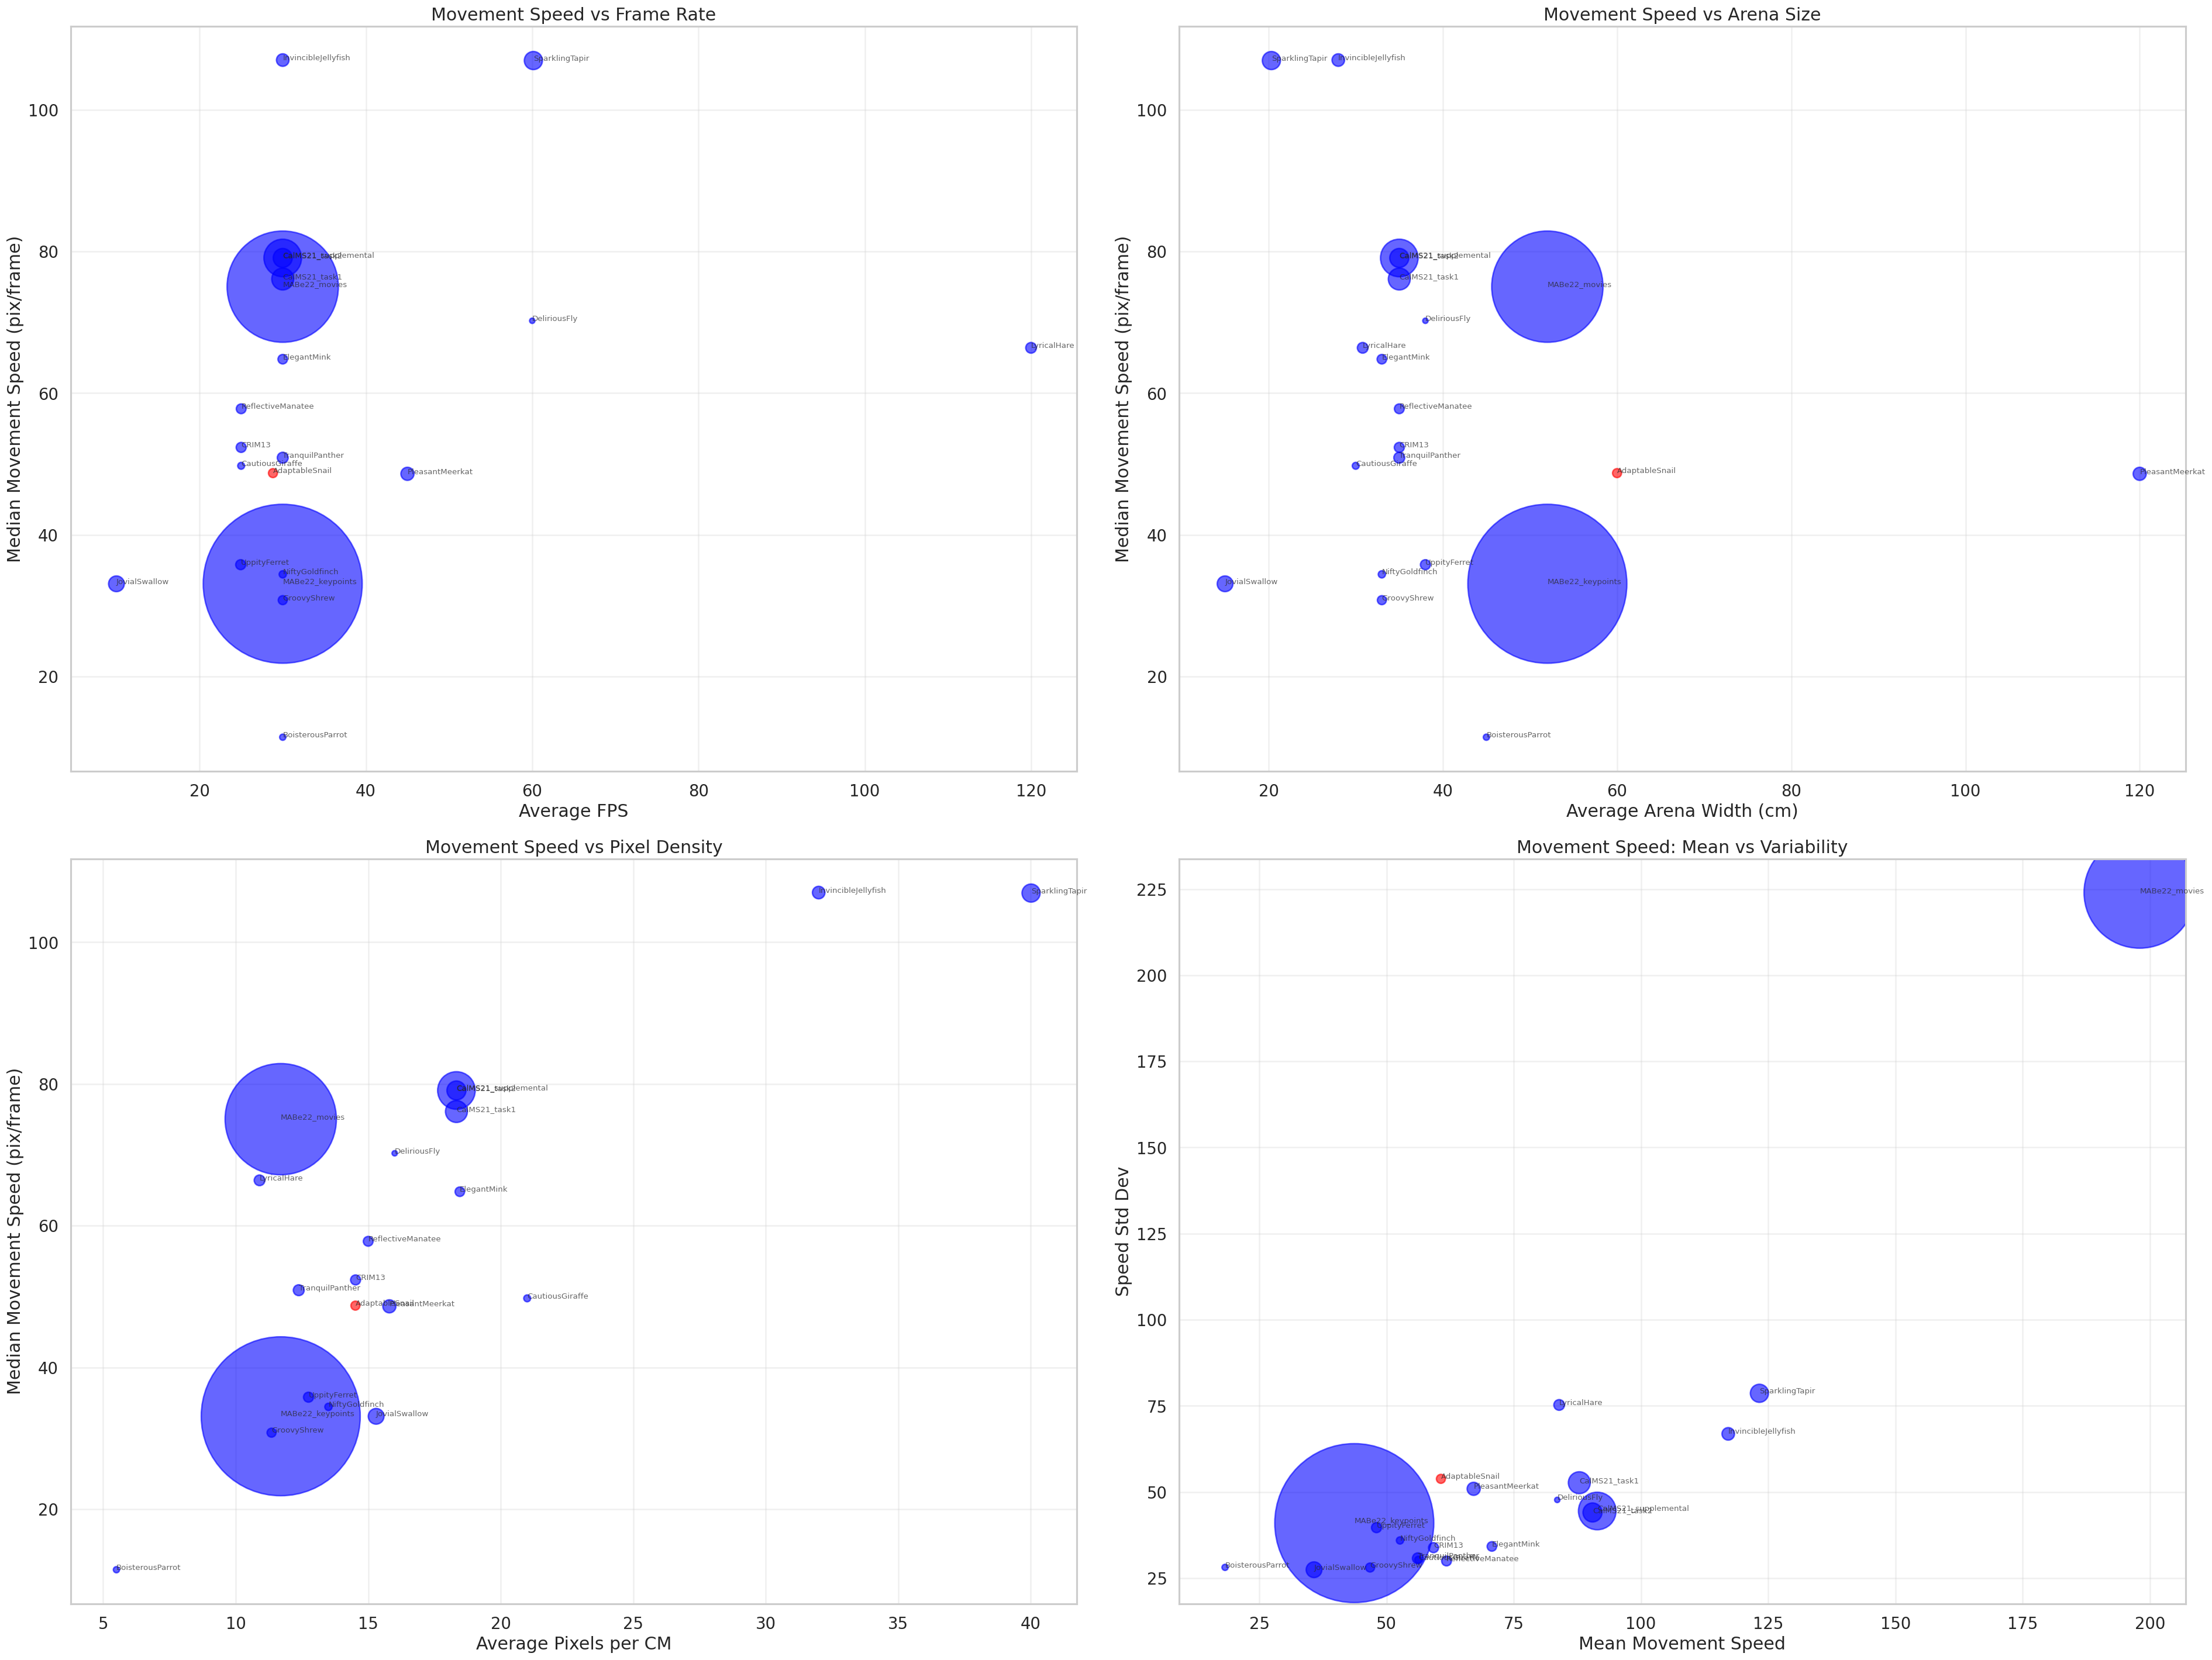

In [18]:
# Correlate movement characteristics with video metadata
lab_metadata_comparison = []

for lab_id in lab_tracking_stats.keys():
    lab_videos = train[train['lab_id'] == lab_id]

    if lab_id in lab_tracking_stats:
        stats_dict = lab_tracking_stats[lab_id]

        lab_metadata_comparison.append({
            'Lab': lab_id,
            'Median_Speed': np.median(stats_dict['speeds']),
            'Mean_Speed': np.mean(stats_dict['speeds']),
            'Speed_Std': np.std(stats_dict['speeds']),
            'Avg_FPS': lab_videos['frames_per_second'].mean(),
            'Avg_Duration': lab_videos['video_duration_sec'].mean(),
            'Avg_Arena_Width': lab_videos['arena_width_cm'].mean(),
            'Avg_Pix_Per_Cm': lab_videos['pix_per_cm_approx'].mean(),
            'N_Videos': len(lab_videos)
        })

metadata_df = pd.DataFrame(lab_metadata_comparison)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(32, 24))

# Speed vs FPS
ax = axes[0, 0]
colors = ['red' if lab == 'AdaptableSnail' else 'blue' for lab in metadata_df['Lab']]
ax.scatter(metadata_df['Avg_FPS'], metadata_df['Median_Speed'], 
           s=metadata_df['N_Videos']*5, alpha=0.6, c=colors)
for i, lab in enumerate(metadata_df['Lab']):
    ax.annotate(lab, (metadata_df['Avg_FPS'].iloc[i], metadata_df['Median_Speed'].iloc[i]), 
                fontsize=8, alpha=0.7)
ax.set_xlabel('Average FPS')
ax.set_ylabel('Median Movement Speed (pix/frame)')
ax.set_title('Movement Speed vs Frame Rate')
ax.grid(alpha=0.3)

# Speed vs Arena Size
ax = axes[0, 1]
ax.scatter(metadata_df['Avg_Arena_Width'], metadata_df['Median_Speed'], 
           s=metadata_df['N_Videos']*5, alpha=0.6, c=colors)
for i, lab in enumerate(metadata_df['Lab']):
    ax.annotate(lab, (metadata_df['Avg_Arena_Width'].iloc[i], metadata_df['Median_Speed'].iloc[i]), 
                fontsize=8, alpha=0.7)
ax.set_xlabel('Average Arena Width (cm)')
ax.set_ylabel('Median Movement Speed (pix/frame)')
ax.set_title('Movement Speed vs Arena Size')
ax.grid(alpha=0.3)

# Speed vs Pixel Density
ax = axes[1, 0]
ax.scatter(metadata_df['Avg_Pix_Per_Cm'], metadata_df['Median_Speed'], 
           s=metadata_df['N_Videos']*5, alpha=0.6, c=colors)
for i, lab in enumerate(metadata_df['Lab']):
    ax.annotate(lab, (metadata_df['Avg_Pix_Per_Cm'].iloc[i], metadata_df['Median_Speed'].iloc[i]), 
                fontsize=8, alpha=0.7)
ax.set_xlabel('Average Pixels per CM')
ax.set_ylabel('Median Movement Speed (pix/frame)')
ax.set_title('Movement Speed vs Pixel Density')
ax.grid(alpha=0.3)

# Speed variability
ax = axes[1, 1]
ax.scatter(metadata_df['Mean_Speed'], metadata_df['Speed_Std'], 
           s=metadata_df['N_Videos']*5, alpha=0.6, c=colors)
for i, lab in enumerate(metadata_df['Lab']):
    ax.annotate(lab, (metadata_df['Mean_Speed'].iloc[i], metadata_df['Speed_Std'].iloc[i]), 
                fontsize=8, alpha=0.7)
ax.set_xlabel('Mean Movement Speed')
ax.set_ylabel('Speed Std Dev')
ax.set_title('Movement Speed: Mean vs Variability')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "movement_vs_video_properties_by_lab.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


 ## 9. Normalized Movement Comparison (Pixels → CM/sec)


NORMALIZED MOVEMENT SPEEDS (CM/SEC)


,Lab,Normalized_Speed_CM_Sec,Median_Speed,Avg_FPS,Avg_Pix_Per_Cm
12,LyricalHare,730.979951,66.396423,120.001667,10.900000
7,DeliriousFly,263.336283,70.213257,60.008333,16.000000
14,MABe22_movies,192.376063,75.026665,30.000000,11.700000
18,SparklingTapir,160.724023,106.929886,60.144928,40.014493
16,PleasantMeerkat,138.471063,48.618729,45.000000,15.800000
3,CalMS21_supplemental,129.420479,79.075912,30.000000,18.330000
5,CalMS21_task2,129.420479,79.075912,30.000000,18.330000
4,CalMS21_task1,124.558419,76.105194,30.000000,18.330000
19,TranquilPanther,123.327939,50.893330,30.000000,12.380000
8,ElegantMink,105.303766,64.789528,30.000000,18.457895


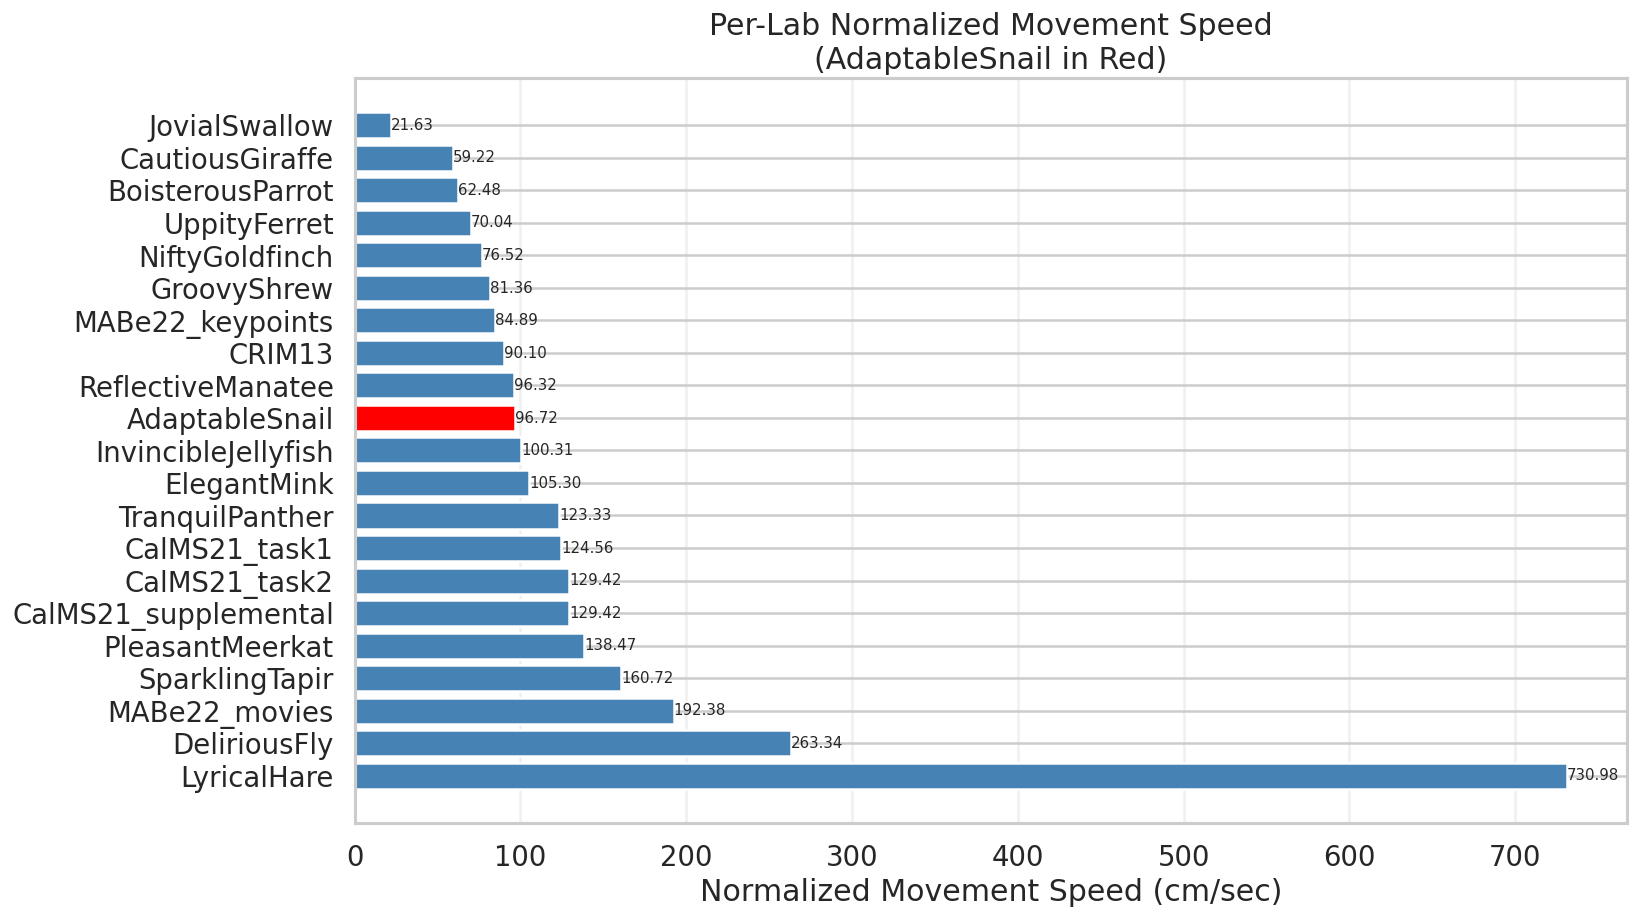

In [14]:
# Normalize movements by pixel density and frame rate
metadata_df['Normalized_Speed_CM_Sec'] = (
    metadata_df['Median_Speed'] / metadata_df['Avg_Pix_Per_Cm'] * metadata_df['Avg_FPS']
)

# Sort by normalized speed
metadata_df_sorted = metadata_df.sort_values('Normalized_Speed_CM_Sec', ascending=False)

print("\n" + "=" * 80)
print("NORMALIZED MOVEMENT SPEEDS (CM/SEC)")
print("=" * 80)
display(metadata_df_sorted[['Lab', 'Normalized_Speed_CM_Sec', 'Median_Speed', 'Avg_FPS', 'Avg_Pix_Per_Cm']])

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['red' if lab == 'AdaptableSnail' else 'steelblue' for lab in metadata_df_sorted['Lab']]
bars = ax.barh(metadata_df_sorted['Lab'], metadata_df_sorted['Normalized_Speed_CM_Sec'], color=colors)
ax.set_xlabel('Normalized Movement Speed (cm/sec)')
ax.set_title('Per-Lab Normalized Movement Speed\n(AdaptableSnail in Red)')
ax.grid(alpha=0.3, axis='x')

# Add values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.2f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / "normalized_movement_speed_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


 ## 10. Key Findings Summary

In [15]:
print("\n" + "=" * 80)
print("KEY FINDINGS: PER-LAB MOVEMENT DIFFERENCES")
print("=" * 80)

if "AdaptableSnail" in lab_tracking_stats and len(comparison_df) > 0:
    n_sig_speed = (comparison_df['Speed_P_Value'] < 0.05).sum()
    n_sig_angle = (comparison_df['Angle_P_Value'] < 0.05).sum()

    adaptable_rank = metadata_df_sorted.reset_index(drop=True)
    adaptable_position = adaptable_rank[adaptable_rank['Lab'] == 'AdaptableSnail'].index[0] + 1

    summary = f"""
ADAPTABLESNAIL (TEST SET LAB) CHARACTERISTICS:
------------------------------------------------
1. Movement Speed:
   - Median: {np.median(lab_tracking_stats['AdaptableSnail']['speeds']):.2f} pixels/frame
   - Normalized: {metadata_df[metadata_df['Lab']=='AdaptableSnail']['Normalized_Speed_CM_Sec'].values[0]:.2f} cm/sec
   - Rank: {adaptable_position} out of {len(metadata_df)} labs

2. Statistical Differences from Other Labs:
   - Significant speed differences: {n_sig_speed}/{len(comparison_df)} labs (p < 0.05)
   - Significant angle differences: {n_sig_angle}/{len(comparison_df)} labs (p < 0.05)

3. Video Properties:
   - FPS: {test['frames_per_second'].values[0]}
   - Arena: {test['arena_width_cm'].values[0]} x {test['arena_height_cm'].values[0]} cm
   - Pixel density: {test['pix_per_cm_approx'].values[0]} pix/cm

RECOMMENDATIONS FOR MODELING:
----------------------------
✓ Use lab-specific normalization for movement features
✓ Consider separate models or domain adaptation for AdaptableSnail
✓ Power transformation (gamma={gamma}) essential for skewed movement distributions
✓ Angular features show significant lab-to-lab variation
✓ Pixel density and FPS normalization critical for cross-lab generalization
"""
    print(summary)

    # Save summary
    with open(figures_dir.parent / "lab_differences_summary.txt", 'w') as f:
        f.write(summary)
else:
    print("⚠️  AdaptableSnail comparison data not available")



KEY FINDINGS: PER-LAB MOVEMENT DIFFERENCES

ADAPTABLESNAIL (TEST SET LAB) CHARACTERISTICS:
------------------------------------------------
1. Movement Speed:
   - Median: 48.72 pixels/frame
   - Normalized: 96.72 cm/sec
   - Rank: 12 out of 21 labs

2. Statistical Differences from Other Labs:
   - Significant speed differences: 20/20 labs (p < 0.05)
   - Significant angle differences: 20/20 labs (p < 0.05)

3. Video Properties:
   - FPS: 30.0
   - Arena: 60.0 x 60.0 cm
   - Pixel density: 16.0 pix/cm

RECOMMENDATIONS FOR MODELING:
----------------------------
✓ Use lab-specific normalization for movement features
✓ Consider separate models or domain adaptation for AdaptableSnail
✓ Power transformation (gamma=0.05) essential for skewed movement distributions
✓ Angular features show significant lab-to-lab variation
✓ Pixel density and FPS normalization critical for cross-lab generalization



 ## 11. Export Lab Statistics

In [16]:
# Save metadata comparison
metadata_df.to_csv(figures_dir.parent / "lab_movement_statistics.csv", index=False)
print(f"\n✅ Lab statistics saved to: {(figures_dir.parent / 'lab_movement_statistics.csv').absolute()}")

if len(comparison_df) > 0:
    comparison_df.to_csv(figures_dir.parent / "adaptablesnail_comparisons.csv", index=False)
    print(f"✅ AdaptableSnail comparisons saved to: {(figures_dir.parent / 'adaptablesnail_comparisons.csv').absolute()}")

print("\n" + "=" * 80)
print("✅ ADVANCED LAB-SPECIFIC EDA COMPLETE")
print("=" * 80)
print(f"📊 Generated comprehensive per-lab movement analysis")
print(f"📁 All outputs in: {figures_dir.absolute()}")



✅ Lab statistics saved to: /home/mingjia-guan/workspaces/MABe-2025/eda/lab_movement_statistics.csv
✅ AdaptableSnail comparisons saved to: /home/mingjia-guan/workspaces/MABe-2025/eda/adaptablesnail_comparisons.csv

✅ ADVANCED LAB-SPECIFIC EDA COMPLETE
📊 Generated comprehensive per-lab movement analysis
📁 All outputs in: /home/mingjia-guan/workspaces/MABe-2025/eda/figures
